In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;
import phi2D_analytical as analytical;
from scipy.signal import find_peaks;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
perturbed_case_directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_11/DN_DELTASCAN_A3_PERTURB_-0.1";
quiescent_case_directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_11/DN_DELTASCAN_A3_QUIESCENT_-0.1";
perturbed_case_data_arrays = reader.fetch_phi2D_data(perturbed_case_directory_path, parallelise = True);
quiescent_case_data_arrays = reader.fetch_phi2D_data(quiescent_case_directory_path, parallelise = True) if quiescent_case_directory_path is not None else None;
dt_diag = reader.fetch_dt_diag(perturbed_case_directory_path);
jacobian_dictionary = reader.fetch_jacobian(perturbed_case_directory_path);

Found 1201 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done 368 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 1170 out of 1201 | elapsed:    4.3s remaining:    0.1s
[Parallel(n_jobs=16)]: Done 1201 out of 1201 | elapsed:    4.4s finished


Finished compiling data from all files in the directory.
Found 1201 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 512 tasks      | elapsed:    1.5s
[Parallel(n_jobs=16)]: Done 1201 out of 1201 | elapsed:    3.7s finished


Finished compiling data from all files in the directory.


In [3]:
def plot_gam_damping(phi2D_list, dt_diag, jacobian_dictionary, GAM_frequency, effective_radius = None, quiescent_phi2D_list = None, skip_peaks = [0, 0], title_suffix = ""):
	# We start with Phi_00.
	fs_avg_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, jacobian_dictionary);

	if quiescent_phi2D_list is not None:

		quiescent_radial_time_series = utils.generate_poloidally_averaged_time_series(quiescent_phi2D_list, jacobian_dictionary);
		fs_avg_time_series = fs_avg_time_series - quiescent_radial_time_series;

	fs_avg_time_series_at_r = gys_utils.slice_at_effective_radius(fs_avg_time_series, effective_radius);
	radially_averaged_time_series = gys_utils.radial_average_1D(fs_avg_time_series, jacobian_dictionary);

	# The values to be plotted.
	decay_signal_xr = fs_avg_time_series_at_r - radially_averaged_time_series;
	decay_signal = decay_signal_xr.values;
	time_range = gys_utils.generate_time_range_by_series(decay_signal, dt_diag);
	
	# Peak isolation.
	minimum_distance = 0.5 * (1 / GAM_frequency) * (1 / dt_diag);
	print(f"Setting minimum distance for interpolation to be {minimum_distance: .3} in code units.");
	peak_indices, _ = find_peaks(decay_signal, distance = minimum_distance);
	peak_times = time_range[peak_indices][skip_peaks[0] : -skip_peaks[1]];
	peak_values = decay_signal[peak_indices][skip_peaks[0] : -skip_peaks[1]];
	print(f"Found {len(peak_indices)} peaks.");

	# Fitting.
	log_peaks = np.log(peak_values);
	damping_rate, log_amplitude = np.polyfit(peak_times, log_peaks, 1);
	fitted_line = np.exp(log_amplitude) * np.exp(damping_rate * time_range);
	print("Plotting...");

	# Figure plotting logic.
	_, ax = plt.subplots(figsize = (10, 6));
	ax.semilogy(time_range, decay_signal, label = "Signal", color = "red", linestyle = "solid");
	ax.plot(time_range, fitted_line, label = "Fitted Exponential Decay", color = "blue", linestyle = "--");
	ax.scatter(peak_times, np.abs(peak_values), label = "Peaks", color = "black", marker = "o");
	plt.suptitle(fr"GAM growth rate extraction, $\rho$ = {effective_radius : .2f}, {title_suffix}", fontsize = 16);
	ax.set_title(fr"$\gamma \Omega_i^{{-1}} = {damping_rate: .3e}$", fontsize = 16);
	ax.set_xlabel(r"time [GYSELA code units]", fontsize = 16, labelpad = 10);
	ax.set_ylabel(r"$\phi_{00} - \langle \phi_{00} \rangle_{r}$", fontsize = 16, labelpad = 10);
	ax.grid(True, which = "major", linestyle = ":", color = "gray", linewidth = 1);
	ax.tick_params(axis = "both", which = "major", labelsize = 14, direction = "in");
	plt.legend(frameon = True, loc = "lower right");
	plt.tight_layout();
	plt.show();

In [4]:
# -------------------------------------------------------------------
# ------------------- -----Benchmarking. ----------------------------
# -------------------------------------------------------------------

def collate_gam_growth_rate_data(decay_signal, dt_diag, GAM_frequency, skip_peaks = (0, 0)):

	fallback_output = {
		"damping_rate": np.nan, "log_amplitude": np.nan, "r_squared": np.nan,
		"peak_indices": np.array([], dtype = int),
		"peak_times": np.array([]), "peak_values": np.array([]),
		"peak_count": 0, "success": False,
	};

	minimum_distance = 0.5 * (1 / GAM_frequency) * (1 / dt_diag);
	peak_indices, _ = find_peaks(decay_signal, distance = minimum_distance);
	time_range = gys_utils.generate_time_range_by_series(decay_signal, dt_diag);
	
	# NB: skip_peaks[1] == 0 would return an empty array.
	end_slice = -skip_peaks[1] if skip_peaks[1] > 0 else None;
	peak_indices = peak_indices[skip_peaks[0] : end_slice];
	
	# Need at least 3 peaks for a meaningful fit.
	if len(peak_indices) < 3:
		return fallback_output;
	
	peak_times = time_range[peak_indices];
	peak_values = decay_signal[peak_indices];
	
	if np.any(peak_values <= 0):
		return fallback_output;
	
	log_peaks = np.log(peak_values);
	damping_rate, log_amplitude = np.polyfit(peak_times, log_peaks, 1);
	
	# R^2 of the log-linear fit.
	log_predicted = damping_rate * peak_times + log_amplitude;
	sum_of_squares_residual = np.sum((log_peaks - log_predicted) ** 2);
	sum_of_squares_total = np.sum((log_peaks - np.mean(log_peaks)) ** 2);
	r_squared = 1 - (sum_of_squares_residual / sum_of_squares_total) if sum_of_squares_total > 0 else np.nan;
	
	return {
		"damping_rate": damping_rate,
		"log_amplitude": log_amplitude,
		"r_squared": r_squared,
		"peak_indices": peak_indices,
		"peak_times": peak_times,
		"peak_values": peak_values,
		"peak_count": len(peak_indices),
		"success": True
	};

def build_time_series(phi2D_list, jacobian_dictionary, quiescent_phi2D_list = None):

	fs_avg_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, jacobian_dictionary);

	if quiescent_phi2D_list is not None:

		quiescent_radial_time_series = utils.generate_poloidally_averaged_time_series(quiescent_phi2D_list, jacobian_dictionary);
		fs_avg_time_series = fs_avg_time_series - quiescent_radial_time_series;
	
	radially_averaged_time_series = gys_utils.radial_average_1D(fs_avg_time_series, jacobian_dictionary);
	return fs_avg_time_series - radially_averaged_time_series;

def scan_gam_damping_over_radius(phi2D_list, dt_diag, jacobian_dictionary, GAM_frequency, quiescent_phi2D_list = None, skip_peaks = (0, 0), r_squared_threshold = 0.99):
	# NB: this is the entry point.
	decay_signal_2d = build_time_series(phi2D_list, jacobian_dictionary, quiescent_phi2D_list);
	r_values = decay_signal_2d.coords["r"].values;
	r_size = len(r_values);
	
	# Set up dummy arrays.
	damping_rates = np.full(r_size, np.nan);
	r_squareds = np.full(r_size, np.nan);
	peak_counts = np.zeros(r_size, dtype = int);
	successes = np.zeros(r_size, dtype = bool);
	
	for radial_index in range(r_size):
		# Slice at r.
		signal_at_r = decay_signal_2d.isel(r = radial_index).values;
		result = collate_gam_growth_rate_data(signal_at_r, dt_diag, GAM_frequency, skip_peaks = skip_peaks);
		damping_rates[radial_index] = result["damping_rate"]
		r_squareds[radial_index] = result["r_squared"]
		peak_counts[radial_index] = result["peak_count"]
		successes[radial_index] = result["success"]
	
	physical_data = xr.Dataset(
		{
			"damping_rate": ("r", damping_rates),
			"r_squared": ("r", r_squareds),
			"peak_count": ("r", peak_counts),
			"success": ("r", successes),
		},
		coords = {"r": r_values},
	);
	
	# Identify plateau.
	plateau_mask = (physical_data["r_squared"] > r_squared_threshold) & physical_data["success"];
	# Just an array of booleans at indices where we have r_squared ~ 1.
	plateau_mask_values = plateau_mask.values;
	
	if plateau_mask_values.any():

		# Matches indices to actual damping rates.
		growth_rate_plateau = damping_rates[plateau_mask_values];
		statistical_data = {
			"r_plateau": r_values[plateau_mask_values],
			"gamma_plateau": growth_rate_plateau,
			"gamma_mean": float(np.mean(growth_rate_plateau)),
			"gamma_std": float(np.std(growth_rate_plateau)),
		}

	else:
		# Fallback case.
		statistical_data = {
			"r_plateau": np.array([]),
			"gamma_plateau": np.array([]),
			"gamma_mean": np.nan,
			"gamma_std": np.nan,
		}
	
	# Most suitable radius, which we define as the max R^2 among points which yielded successes.
	if successes.any():

		valid_r_squared = np.where(successes, r_squareds, -np.inf);
		best_radial_array_index = int(np.argmax(valid_r_squared));
		statistical_data["best_radial_index"] = float(r_values[best_radial_array_index]);
		statistical_data["best_growth_rate"] = float(damping_rates[best_radial_array_index]);

	else:

		statistical_data["best_radial_index"] = np.nan;
		statistical_data["best_growth_rate"] = np.nan;
	
	return physical_data, statistical_data;

In [5]:
def plot_gam_damping_radial_scan(physical_data, statistical_data, r_squared_threshold = 0.95, title_suffix = ""):

	fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5));
	r = physical_data["r"].values;
	rho = r / len(r);
	
	ax1.plot(rho, physical_data["damping_rate"].values, "k-", lw = 1.5);

	if len(statistical_data["r_plateau"]) > 0:

		ax1.scatter(statistical_data["r_plateau"] / len(r), statistical_data["gamma_plateau"], color="red", zorder=3, label="Plateau");
		ax1.axhline(statistical_data["gamma_mean"], color="red", linestyle="--", label=fr"$\langle\gamma\rangle = {statistical_data['gamma_mean']:.3e}$");
	
	ax1.set_xlabel(r"$\rho$", fontsize=14);
	ax1.set_ylabel(r"$\gamma \Omega_i^{-1}$", fontsize=14);
	ax1.set_title(r"Damping rate vs. $\rho$", fontsize=14);
	ax1.grid(True, linestyle=":", alpha=0.7);
	ax1.legend(loc="upper left");
	
	ax2.plot(rho, physical_data["r_squared"].values, "k-", lw=1.5)
	ax2.axhline(r_squared_threshold, color="red", linestyle="--",
				label=fr"threshold = {r_squared_threshold}")
	ax2.set_xlabel(r"$\rho$", fontsize=14)
	ax2.set_ylabel(r"$R^2$", fontsize = 14);
	ax2.set_title(r"$R^2$ vs. $\rho$", fontsize = 14);
	ax2.grid(True, linestyle=":", alpha=0.7)
	ax2.legend(loc="lower right")
	
	plt.suptitle(fr"GAM radial scan, $\gamma \Omega_i^{{-1}} $ = {statistical_data["best_growth_rate"]: .3e} at $ \rho$ = {statistical_data["best_radial_index"] / len(physical_data["r"]): .2f}, {title_suffix}", fontsize=16);
	plt.tight_layout()
	plt.show()

In [ ]:
# All requisite data.
effective_radius_simple = utils.find_gam_effective_radius_simple(perturbed_case_data_arrays, jacobian_dictionary, quiescent_case_data_arrays, skip_initial_entries = 0.1);
GAM_frequency = utils.extract_gam_frequency(perturbed_case_data_arrays, dt_diag, jacobian_dictionary, effective_radius_simple);
physical_data, statistical_data = scan_gam_damping_over_radius(
	perturbed_case_data_arrays,
	dt_diag,
	jacobian_dictionary,
	GAM_frequency,
	quiescent_phi2D_list = quiescent_case_data_arrays,
	skip_peaks = [1, 3]);

Setting minimum distance for interpolation to be  12.6 in code units.
Found 47 peaks.
Plotting...


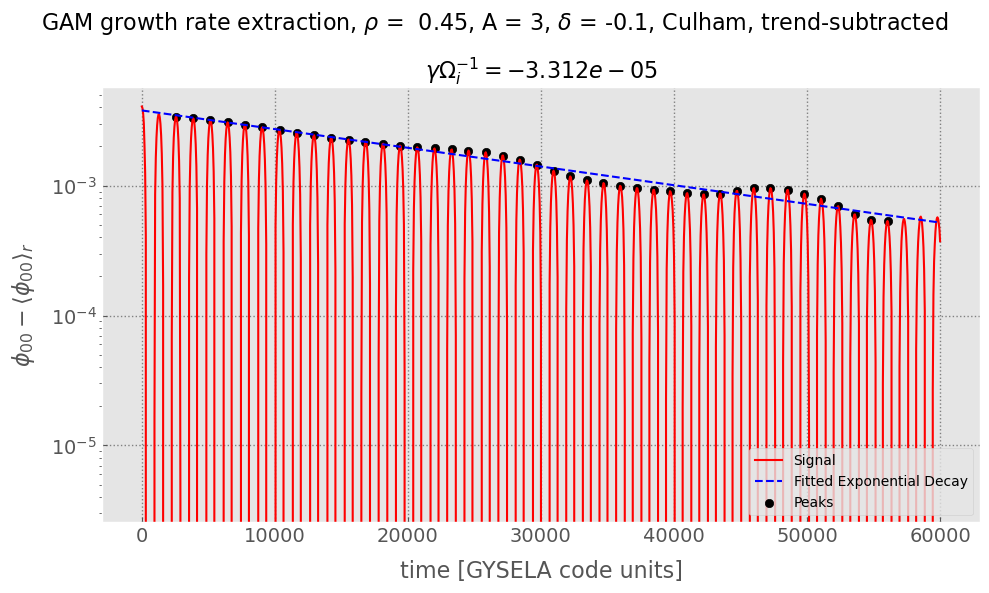

In [7]:

plot_gam_damping(
	perturbed_case_data_arrays, 
	dt_diag, 
	jacobian_dictionary, 
	GAM_frequency, 
	effective_radius = 0.45, 
	quiescent_phi2D_list = quiescent_case_data_arrays, 
	skip_peaks = [1, 3],
	title_suffix = rf"A = 3, $\delta$ = -0.1, Culham, trend-subtracted");

/tmp/ipykernel_1447555/1314221537.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper left");


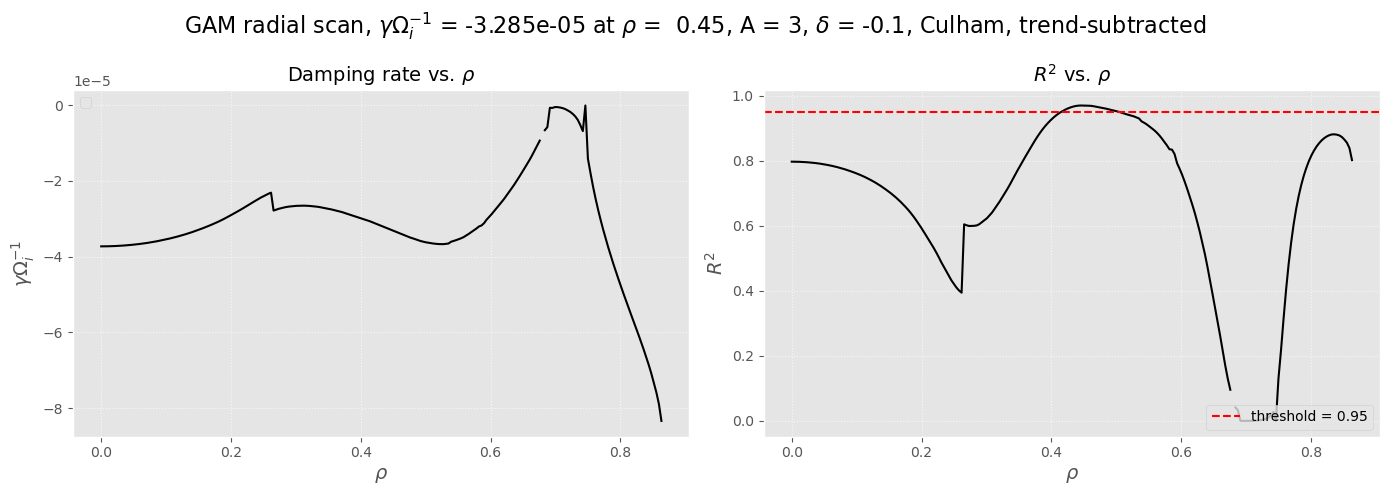

In [8]:
plot_gam_damping_radial_scan(physical_data, statistical_data, title_suffix = fr"A = 3, $\delta$ = -0.1, Culham, trend-subtracted");